In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [3]:
inventory = pd.read_csv(
    "../datasets/inventory/Inventory_Transactions.csv"
)

inventory.head()

,Order_ID,Date,SKU,Qty_Sold,Location,Staff_ID,Revenue,Lead_Time,Risk_Level
0,ORD-501,9/22/2025,SURG-P-02,18,North,Optician_A,1530.0,30,Medium Risk
1,ORD-502,8/16/2025,FRM-M-10,4,North,Optician_C,180.0,30,Medium Risk
2,ORD-503,2/7/2025,SURG-P-02,13,East,Optician_A,1105.0,30,Medium Risk
3,ORD-504,7/10/2025,SURG-P-02,16,West,Surgeon_K,1360.0,30,Medium Risk
4,ORD-505,5/29/2025,LENS-D-01,7,West,Optician_A,87.5,14,Low Risk


In [5]:
inventory.shape

(1415, 9)

In [6]:
inventory.columns

Index(['Order_ID', 'Date', 'SKU', 'Qty_Sold', 'Location', 'Staff_ID',
       'Revenue', 'Lead_Time', 'Risk_Level'],
      dtype='object')

In [7]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    1415 non-null   object 
 1   Date        1415 non-null   object 
 2   SKU         1415 non-null   object 
 3   Qty_Sold    1415 non-null   int64  
 4   Location    1415 non-null   object 
 5   Staff_ID    1415 non-null   object 
 6   Revenue     1415 non-null   float64
 7   Lead_Time   1415 non-null   int64  
 8   Risk_Level  1415 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 99.6+ KB


In [8]:
inventory.describe()

,Qty_Sold,Revenue,Lead_Time
count,1415.000000,1415.000000,1415.000000
mean,12.939929,679.487809,25.043816
std,7.229022,799.562291,11.491196
min,1.000000,4.250000,7.000000
25%,7.000000,112.500000,14.000000
50%,13.000000,388.000000,30.000000
75%,19.000000,935.000000,30.000000
max,25.000000,3750.000000,45.000000


In [9]:
inventory.isnull().sum()

Order_ID      0
Date          0
SKU           0
Qty_Sold      0
Location      0
Staff_ID      0
Revenue       0
Lead_Time     0
Risk_Level    0
dtype: int64

In [10]:
inventory["Date"].head()

0    9/22/2025
1    8/16/2025
2     2/7/2025
3    7/10/2025
4    5/29/2025
Name: Date, dtype: object

In [11]:
inventory["Date"] = pd.to_datetime(
    inventory["Date"]
)

In [12]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order_ID    1415 non-null   object        
 1   Date        1415 non-null   datetime64[ns]
 2   SKU         1415 non-null   object        
 3   Qty_Sold    1415 non-null   int64         
 4   Location    1415 non-null   object        
 5   Staff_ID    1415 non-null   object        
 6   Revenue     1415 non-null   float64       
 7   Lead_Time   1415 non-null   int64         
 8   Risk_Level  1415 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 99.6+ KB


In [14]:
inventory["Year"] = inventory["Date"].dt.year
inventory["Month"] = inventory["Date"].dt.month
inventory["Day"] = inventory["Date"].dt.day
inventory["Weekday"] = inventory["Date"].dt.day_name()

In [15]:
inventory.head()

,Order_ID,Date,SKU,Qty_Sold,Location,Staff_ID,Revenue,Lead_Time,Risk_Level,Year,Month,Day,Weekday
0,ORD-501,2025-09-22,SURG-P-02,18,North,Optician_A,1530.0,30,Medium Risk,2025,9,22,Monday
1,ORD-502,2025-08-16,FRM-M-10,4,North,Optician_C,180.0,30,Medium Risk,2025,8,16,Saturday
2,ORD-503,2025-02-07,SURG-P-02,13,East,Optician_A,1105.0,30,Medium Risk,2025,2,7,Friday
3,ORD-504,2025-07-10,SURG-P-02,16,West,Surgeon_K,1360.0,30,Medium Risk,2025,7,10,Thursday
4,ORD-505,2025-05-29,LENS-D-01,7,West,Optician_A,87.5,14,Low Risk,2025,5,29,Thursday


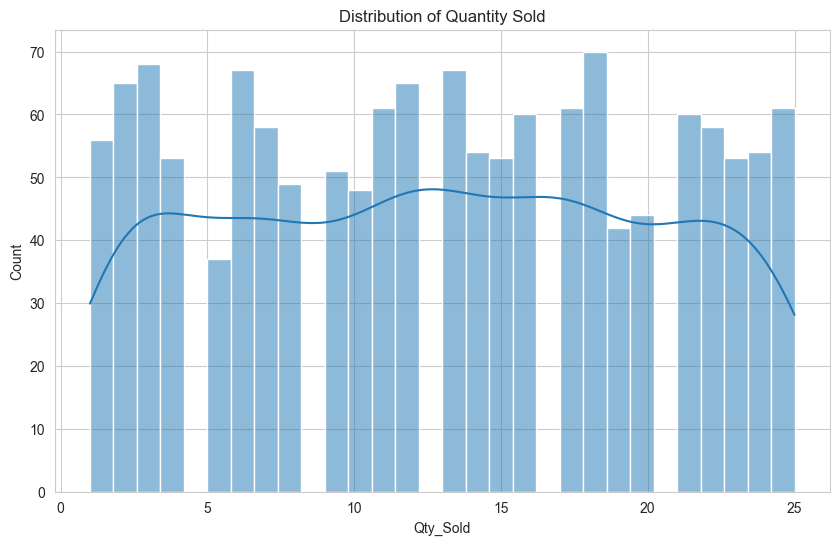

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    inventory["Qty_Sold"],
    bins=30,
    kde=True
)

plt.title("Distribution of Quantity Sold")
plt.show()

Is Qty_Sold normally distributed?
-No, it is not normally distributed. A normal distribution would present a bell-shaped curve that peaks clearly in the center and tapers off evenly toward both edges.

Is it skewed?
-No, it shows no significant skewness. Because the counts are fairly evenly spread from the minimum to the maximum values, the data is neither stretched to the right (positive skew) nor to the left (negative skew).

Are there outliers?
-No, there are no visible outliers. All observed data points fall neatly within a bounded, continuous range from 1 to 25. There are no isolated bars or lone data points sitting far away from the rest of the distribution.

In [19]:
daily_sales = inventory.groupby(
    "Date"
)["Qty_Sold"].sum()

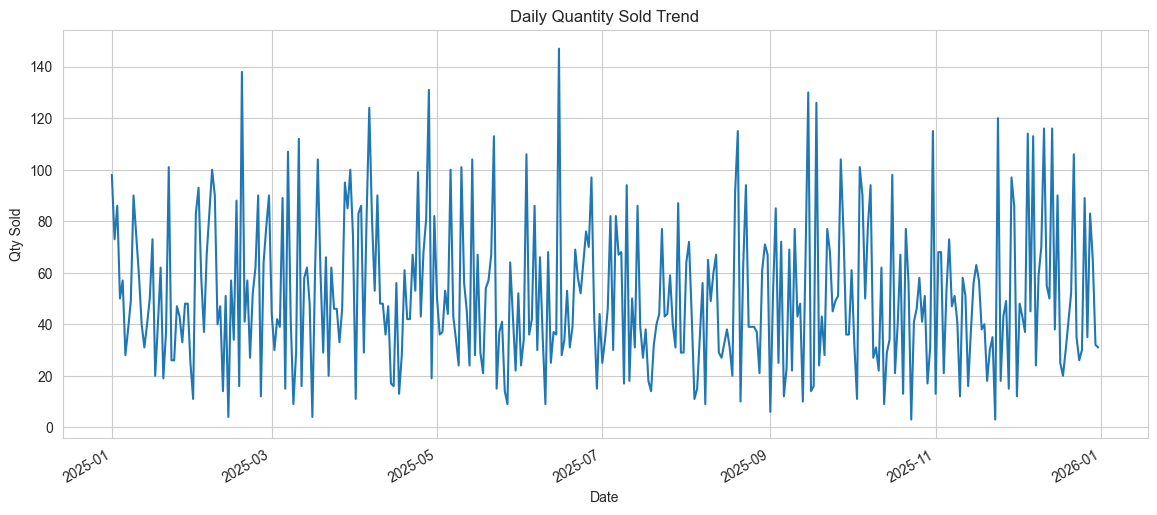

In [21]:
plt.figure(figsize=(14,6))
daily_sales.plot()
plt.title("Daily Quantity Sold Trend")
plt.xlabel("Date")
plt.ylabel("Qty Sold")
plt.show()

In [22]:
top_skus = inventory.groupby(
    "SKU"
)["Qty_Sold"].sum().sort_values(
    ascending=False
).head(10)

top_skus

SKU
FRM-W-12     2819
LENS-D-01    2799
SURG-L-01    2591
SOL-S-01     2545
LENS-M-02    2538
SURG-P-02    2526
FRM-M-10     2492
Name: Qty_Sold, dtype: int64

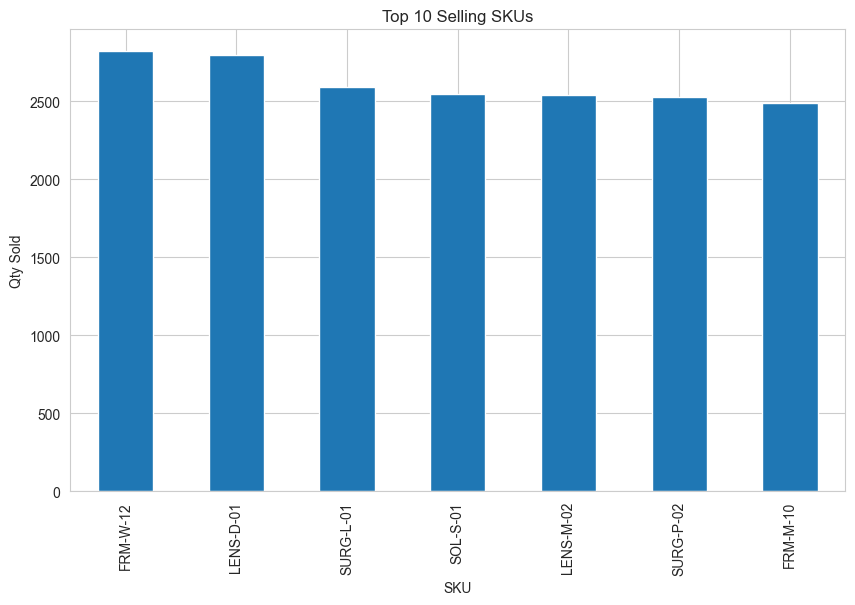

In [23]:
plt.figure(figsize=(10,6))

top_skus.plot(kind="bar")

plt.title("Top 10 Selling SKUs")
plt.ylabel("Qty Sold")
plt.show()

Which SKU generates highest sales?
-FRM-W-12     2819

In [24]:
location_revenue = inventory.groupby(
    "Location"
)["Revenue"].sum().sort_values(ascending=False)

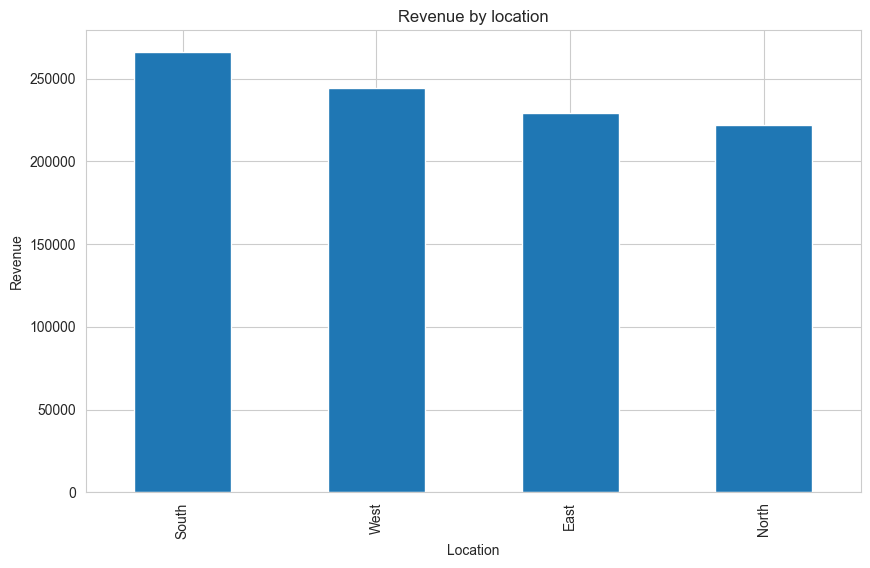

In [25]:
plt.figure(figsize=(10,6))
location_revenue.plot(kind="bar")
plt.title("Revenue by location")
plt.ylabel("Revenue")
plt.show()

Which location performs best?
-South

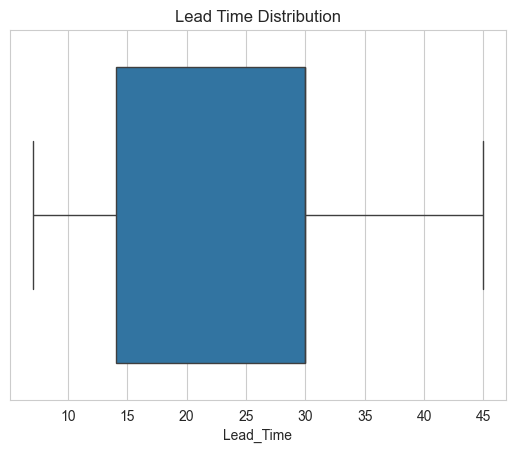

In [26]:
sns.boxplot(
    x=inventory["Lead_Time"]
)
plt.title("Lead Time Distribution")
plt.show()

Are lead times stable?
Yes, relatively stable but with a wide spread.

Any extreme values?
No, there are no extreme values or outliers.

In [27]:
inventory["Risk_Level"].value_counts()

Risk_Level
Medium Risk    805
Low Risk       418
High Risk      192
Name: count, dtype: int64

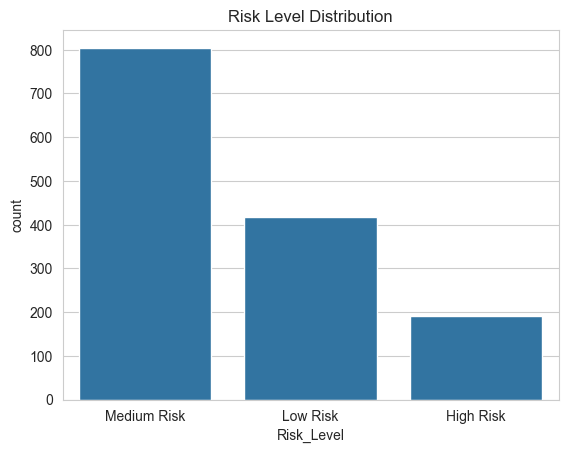

In [28]:
sns.countplot(
    x="Risk_Level",
    data=inventory
)
plt.title("Risk Level Distribution")
plt.show()

How many high-risk transactions exist?
192

In [29]:
numeric_cols=inventory.select_dtypes(
    include=np.number
)

numeric_cols.corr()

,Qty_Sold,Revenue,Lead_Time,Year,Month,Day
Qty_Sold,1.000000,0.492608,0.029386,NaN,-0.044530,-0.020411
Revenue,0.492608,1.000000,0.709326,NaN,0.014886,-0.023483
Lead_Time,0.029386,0.709326,1.000000,NaN,0.012607,-0.019038
Year,NaN,NaN,NaN,NaN,NaN,NaN
Month,-0.044530,0.014886,0.012607,NaN,1.000000,0.008093
Day,-0.020411,-0.023483,-0.019038,NaN,0.008093,1.000000


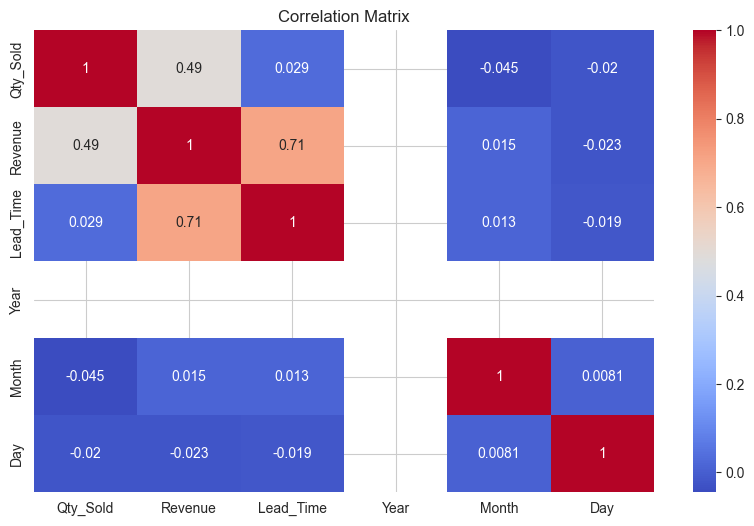

In [32]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Which features correlate with Qty_Sold?
-Revenue


## Key Findings

1. Highest Selling SKU:
   FRM-W-12 (2819 units sold)

2. Best Performing Location:
   South region generated the highest revenue.

3. Qty_Sold Distribution:
   The target variable is well distributed with no significant skewness or extreme outliers.

4. Daily Sales Trend:
   Sales fluctuate considerably over time with no strong upward or downward trend.

5. Lead Time Behavior:
   Lead times range from approximately 7 to 45 days and remain relatively stable.

6. Risk Level Observation:
   Medium Risk transactions dominate the dataset, while High Risk transactions occur less frequently.

7. Correlation Analysis:
   Revenue shows a moderate positive correlation with Qty_Sold (0.49), making it a potentially useful predictive feature.

8. Can Qty_Sold Be Predicted?
   Yes.

Reason:
The dataset contains meaningful numerical and categorical features, a balanced target variable, and sufficient historical records for machine learning-based demand forecasting.